# 数据分析与可视化部分（稀疏矩阵处理、活跃用户与热门电影筛选）

主要流程：处理原始稀疏矩阵`user_item_matrix.csv`，完成整体统计分析、阈值选择、迭代过滤、可视化展示，并将处理后的矩阵保存至`user_item_matrix_sparse_filtered.csv`

## 环境与路径准备
这一部分导入分析所需库，统一图表样式，并自动定位项目根目录与数据文件路径。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 30)

# 统一图表样式，保证中文标签正常显示
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path) -> Path:
    # 从当前目录逐级向上查找，确保 notebook 在不同启动位置都能找到数据目录
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "cleaned_data" / "user_item_matrix.csv").exists():
            return candidate
    raise FileNotFoundError("未找到项目根目录，请确认 notebook 位于仓库内。")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data" / "cleaned_data"
MATRIX_PATH = DATA_DIR / "user_item_matrix.csv"
FILTERED_PATH = DATA_DIR / "user_item_matrix_sparse_filtered.csv"
RATINGS_PATH = DATA_DIR / "cleaned_ratings.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MATRIX_PATH:", MATRIX_PATH)
print("FILTERED_PATH:", FILTERED_PATH)
print("RATINGS_PATH:", RATINGS_PATH)

PROJECT_ROOT: D:\Movie-Recommender-System
MATRIX_PATH: D:\Movie-Recommender-System\data\cleaned_data\user_item_matrix.csv
FILTERED_PATH: D:\Movie-Recommender-System\data\cleaned_data\user_item_matrix_sparse_filtered.csv
RATINGS_PATH: D:\Movie-Recommender-System\data\cleaned_data\cleaned_ratings.csv


## 辅助函数
这里定义后续会重复使用的统计函数、块密度计算函数，以及迭代过滤函数。

In [2]:
def matrix_sparsity(matrix: pd.DataFrame) -> float:
    # 稀疏度 = 缺失评分单元数 / 总单元数
    return float(matrix.isna().sum().sum() / matrix.size)


def matrix_summary(matrix: pd.DataFrame) -> pd.Series:
    user_counts = matrix.notna().sum(axis=1)
    movie_counts = matrix.notna().sum(axis=0)
    ratings = int(matrix.notna().sum().sum())
    total = int(matrix.size)
    return pd.Series(
        {
            "users": int(matrix.shape[0]),
            "movies": int(matrix.shape[1]),
            "ratings": ratings,
            "cells": total,
            "density": 1 - ratings / total,
            "sparsity": ratings / total,
            "avg_user_ratings": float(user_counts.mean()),
            "avg_movie_ratings": float(movie_counts.mean()),
            "median_user_ratings": float(user_counts.median()),
            "median_movie_ratings": float(movie_counts.median()),
        }
    )


def block_density(binary_matrix: pd.DataFrame, row_bins: int = 40, col_bins: int = 80) -> np.ndarray:
    # 将大矩阵按块压缩，便于用热力图观察评分分布密度
    arr = binary_matrix.to_numpy(dtype=float)
    row_splits = np.array_split(arr, row_bins, axis=0)
    blocks = []
    for row_block in row_splits:
        col_splits = np.array_split(row_block, col_bins, axis=1)
        blocks.append([float(col.mean()) if col.size else np.nan for col in col_splits])
    return np.asarray(blocks)


def iterative_sparse_filter_matrix(
    matrix: pd.DataFrame,
    min_user_ratings: int,
    min_movie_ratings: int,
    tolerance: float = 1e-4,  # 稀疏度变化足够小时停止迭代
    max_iter: int = 20,
):
    current = matrix.copy()
    history = []
    prev_sparsity = None

    for iteration in range(1, max_iter + 1):
        before_users, before_movies = current.shape
        before_ratings = int(current.notna().sum().sum())

        user_counts = current.notna().sum(axis=1)
        movie_counts = current.notna().sum(axis=0)

        keep_users = user_counts[user_counts >= min_user_ratings].index
        keep_movies = movie_counts[movie_counts >= min_movie_ratings].index

        next_matrix = current.loc[keep_users, keep_movies]
        after_users, after_movies = next_matrix.shape
        after_ratings = int(next_matrix.notna().sum().sum())
        after_sparsity = matrix_sparsity(next_matrix) if after_users and after_movies else 1.0
        sparsity_delta = None if prev_sparsity is None else abs(after_sparsity - prev_sparsity)

        history.append(
            {
                "iteration": iteration,
                "users_before": before_users,
                "movies_before": before_movies,
                "ratings_before": before_ratings,
                "users_after": after_users,
                "movies_after": after_movies,
                "ratings_after": after_ratings,
                "removed_users": before_users - after_users,
                "removed_movies": before_movies - after_movies,
                "removed_ratings": before_ratings - after_ratings,
                "sparsity_after": after_sparsity,
                "sparsity_delta": np.nan if sparsity_delta is None else sparsity_delta,
            }
        )

        if sparsity_delta is not None and sparsity_delta < tolerance:
            current = next_matrix
            break
        if next_matrix.shape == current.shape:
            current = next_matrix
            break

        prev_sparsity = after_sparsity
        current = next_matrix

    return current, pd.DataFrame(history)


def plot_distribution(ax, values, title, xlabel, color):
    sns.histplot(values, bins=30, ax=ax, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("用户数" if "用户" in title else "电影数")
    ax.set_yscale("log")

## 原始矩阵概览
先读取原始用户-电影矩阵与评分明细，并输出基础规模统计表和分位数表，作为后续阈值选择的依据。

In [3]:
initial_matrix = pd.read_csv(MATRIX_PATH, index_col=0)
# 读入用户-电影评分矩阵，并保留 userId 作为行索引
initial_matrix.index.name = "userId"
initial_matrix.columns = pd.to_numeric(initial_matrix.columns, errors="ignore")

ratings = pd.read_csv(RATINGS_PATH)
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], errors="coerce")

user_rating_counts = initial_matrix.notna().sum(axis=1)
movie_rating_counts = initial_matrix.notna().sum(axis=0)

baseline = matrix_summary(initial_matrix)
display(pd.DataFrame([baseline]).T.rename(columns={0: "value"}))

summary_table = pd.DataFrame(
    {
        "指标": ["用户数", "电影数", "评分数", "矩阵单元数", "稀疏率", "密度", "用户平均评分数", "电影平均评分数"],
        "数值": [
            int(baseline["users"]),
            int(baseline["movies"]),
            int(baseline["ratings"]),
            int(baseline["cells"]),
            f"{baseline['sparsity']:.2%}",
            f"{baseline['density']:.2%}",
            f"{baseline['avg_user_ratings']:.2f}",
            f"{baseline['avg_movie_ratings']:.2f}",
        ],
    }
)

display(summary_table)

quantile_table = pd.DataFrame(
    {
        "分位点": ["10%", "25%", "50%", "75%", "90%", "95%", "99%"],
        "用户评分数": user_rating_counts.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2).to_list(),
        "电影评分数": movie_rating_counts.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2).to_list(),
    }
)
display(quantile_table)

C:\Users\述\AppData\Local\Temp\ipykernel_62920\3775108802.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  initial_matrix.columns = pd.to_numeric(initial_matrix.columns, errors="ignore")


,value
users,6.100000e+02
movies,9.724000e+03
ratings,1.008360e+05
cells,5.931640e+06
density,9.830003e-01
sparsity,1.699968e-02
avg_user_ratings,1.653049e+02
avg_movie_ratings,1.036981e+01
median_user_ratings,7.050000e+01
median_movie_ratings,3.000000e+00


,指标,数值
0,用户数,610
1,电影数,9724
2,评分数,100836
3,矩阵单元数,5931640
4,稀疏率,1.70%
5,密度,98.30%
6,用户平均评分数,165.30
7,电影平均评分数,10.37


,分位点,用户评分数,电影评分数
0,10%,24.00,1.00
1,25%,35.00,1.00
2,50%,70.50,3.00
3,75%,168.00,9.00
4,90%,400.30,27.00
5,95%,610.75,47.00
6,99%,1256.22,114.54


## 原始分布图
下面两张图分别展示原始矩阵中用户评分数分布和电影评分数分布，用来观察长尾特征。

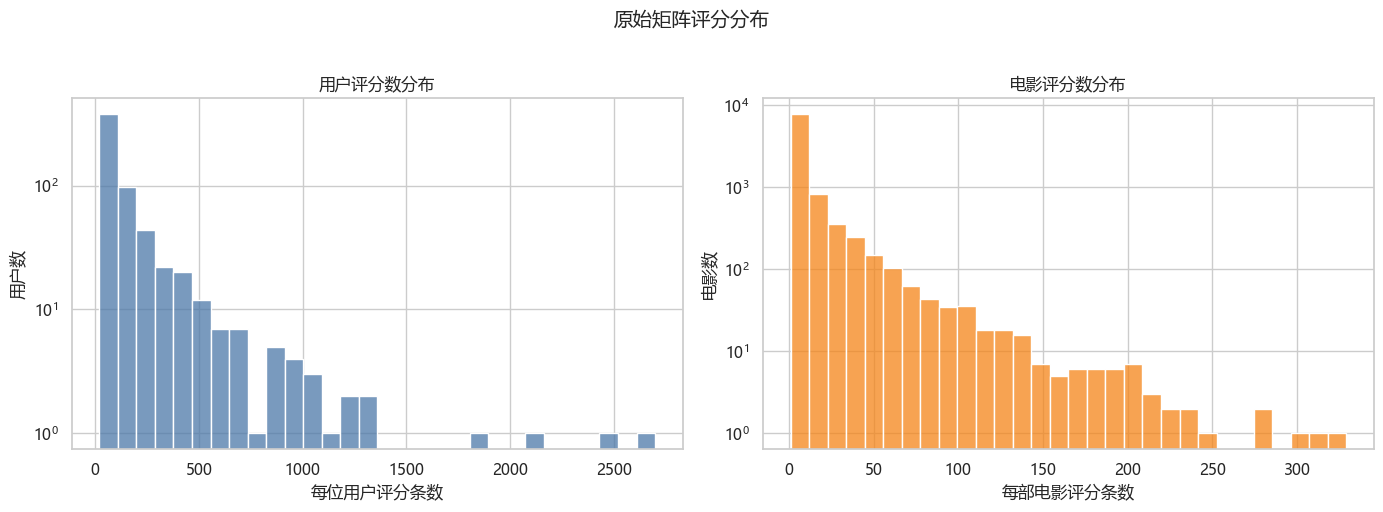

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_distribution(axes[0], user_rating_counts, "用户评分数分布", "每位用户评分条数", "#4C78A8")
plot_distribution(axes[1], movie_rating_counts, "电影评分数分布", "每部电影评分条数", "#F58518")
fig.suptitle("原始矩阵评分分布", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 原始块密度热力图
这张热力图将原始矩阵压缩成较小的网格，用颜色深浅表示各区域评分占比。

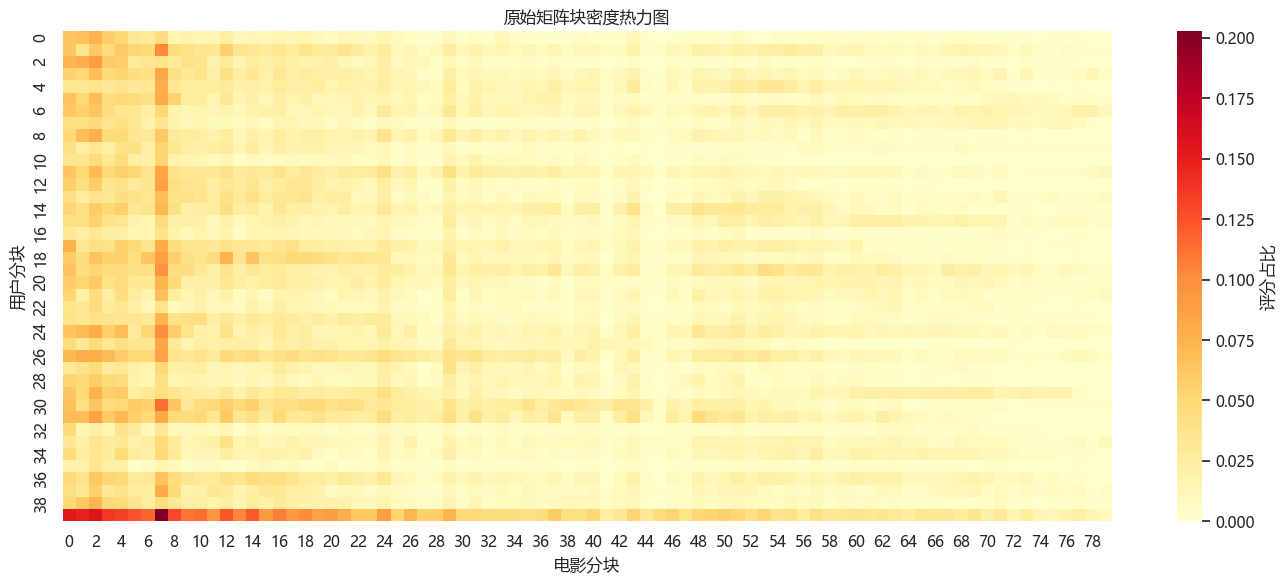

In [5]:
density_before = block_density(initial_matrix.notna(), row_bins=40, col_bins=80)
density_after_preview = None

plt.figure(figsize=(14, 6))
sns.heatmap(density_before, cmap="YlOrRd", cbar_kws={"label": "评分占比"})
plt.title("原始矩阵块密度热力图")
plt.xlabel("电影分块")
plt.ylabel("用户分块")
plt.tight_layout()
plt.show()

## 评分时序图
这一部分从时间维度观察评分活跃度变化，并同时展示月均评分走势。

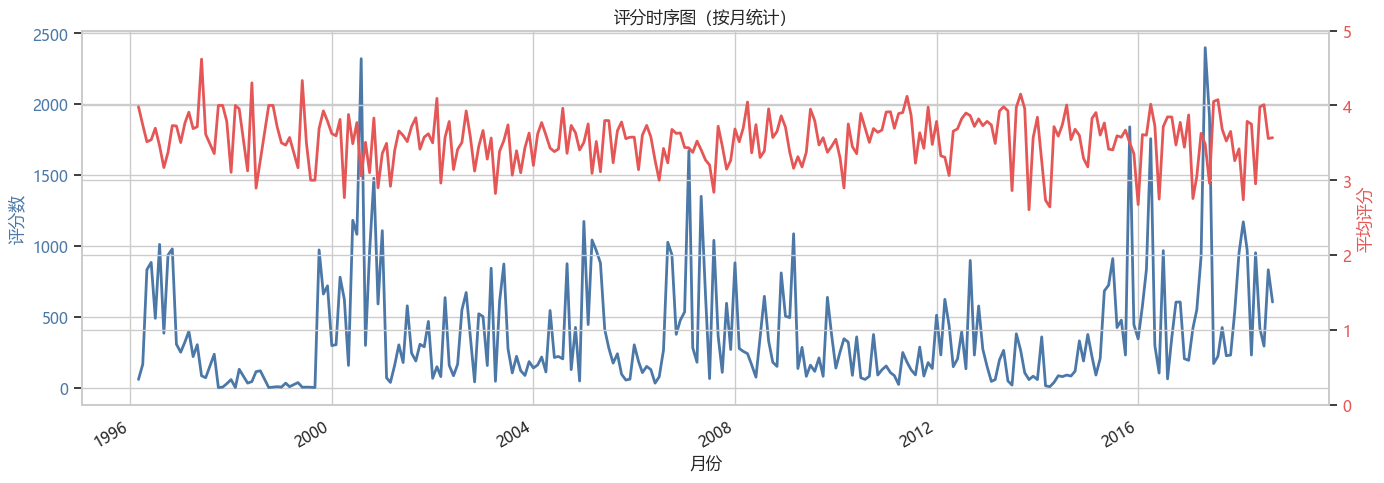

In [6]:
monthly = (
    # 先按月聚合，观察评分活跃度与平均评分的时间变化
    ratings.dropna(subset=["timestamp"])
    .assign(month=lambda df: df["timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(rating_count=("rating", "size"), avg_rating=("rating", "mean"))
    .reset_index()
    .sort_values("month")
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly["month"], monthly["rating_count"], color="#4C78A8", linewidth=2, label="月度评分数")
ax1.set_ylabel("评分数", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")

ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["avg_rating"], color="#E45756", linewidth=2, label="月均评分")
ax2.set_ylabel("平均评分", color="#E45756")
ax2.tick_params(axis="y", labelcolor="#E45756")
ax2.set_ylim(0, 5)

ax1.set_title("评分时序图（按月统计）")
ax1.set_xlabel("月份")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 阈值选择

从分位数看，用户评分数的中位数约为 70.5，电影评分数的中位数约为 3。为了同时控制活跃用户和热门电影的质量，并避免过度丢失样本，这里先对几个候选阈值做小规模对比，再选择 `user >= 30`、`movie >= 15` 进行正式迭代过滤。

## 候选阈值对比表
先比较几组候选阈值在过滤后得到的矩阵规模、评分保留情况和稀疏度表现。

In [7]:
# 先对几组候选阈值做横向比较，再确定最终过滤标准
candidate_thresholds = [(20, 10), (25, 12), (30, 15), (35, 15), (30, 20)]
sweep_rows = []

for min_user_ratings, min_movie_ratings in candidate_thresholds:
    final_candidate, history_candidate = iterative_sparse_filter_matrix(
        initial_matrix,
        min_user_ratings=min_user_ratings,
        min_movie_ratings=min_movie_ratings,
    )
    sweep_rows.append(
        {
            "min_user_ratings": min_user_ratings,
            "min_movie_ratings": min_movie_ratings,
            "final_users": int(final_candidate.shape[0]),
            "final_movies": int(final_candidate.shape[1]),
            "final_ratings": int(final_candidate.notna().sum().sum()),
            "final_sparsity": matrix_sparsity(final_candidate),
            "iterations": int(len(history_candidate)),
            "last_delta": float(history_candidate["sparsity_delta"].dropna().iloc[-1]) if history_candidate["sparsity_delta"].notna().any() else np.nan,
        }
    )

sweep_df = pd.DataFrame(sweep_rows).sort_values(["min_user_ratings", "min_movie_ratings"]).reset_index(drop=True)
display(sweep_df)

,min_user_ratings,min_movie_ratings,final_users,final_movies,final_ratings,final_sparsity,iterations,last_delta
0,20,10,592,2264,80783,0.939727,3,0.000099
1,25,12,521,1951,75976,0.925255,4,0.000000
2,30,15,475,1617,70454,0.908272,5,0.000077
3,30,20,464,1267,64263,0.890688,4,0.000000
4,35,15,427,1603,68728,0.899591,4,0.000000


## 正式迭代过滤结果
选定阈值后，输出每一轮迭代的矩阵变化情况，便于判断过滤过程是否稳定收敛。

In [8]:
# 最终采用的阈值：保留更活跃的用户和更热门的电影
CHOSEN_MIN_USER = 30
CHOSEN_MIN_MOVIE = 15
final_matrix, history_df = iterative_sparse_filter_matrix(
    initial_matrix,
    min_user_ratings=CHOSEN_MIN_USER,
    min_movie_ratings=CHOSEN_MIN_MOVIE,
)

history_df["ratings_retained_ratio"] = history_df["ratings_after"] / int(initial_matrix.notna().sum().sum())
history_df["user_retained_ratio"] = history_df["users_after"] / int(initial_matrix.shape[0])
history_df["movie_retained_ratio"] = history_df["movies_after"] / int(initial_matrix.shape[1])

display(history_df)

,iteration,users_before,movies_before,ratings_before,users_after,movies_after,ratings_after,removed_users,removed_movies,removed_ratings,sparsity_after,sparsity_delta,ratings_retained_ratio,user_retained_ratio,movie_retained_ratio
0,1,610,9724,100836,501,1650,71541,109,8074,29295,0.913457,NaN,0.709479,0.821311,0.169683
1,2,501,1650,71541,476,1630,70661,25,20,880,0.908928,0.004529,0.700752,0.780328,0.167626
2,3,476,1630,70661,476,1619,70510,0,11,151,0.908505,0.000423,0.699254,0.780328,0.166495
3,4,476,1619,70510,475,1619,70482,1,0,28,0.908349,0.000156,0.698977,0.778689,0.166495
4,5,475,1619,70482,475,1617,70454,0,2,28,0.908272,0.000077,0.698699,0.778689,0.166290


## 稀疏度变化曲线
折线图展示从原始矩阵到每轮过滤结果的稀疏度变化，用来直观看收敛过程。

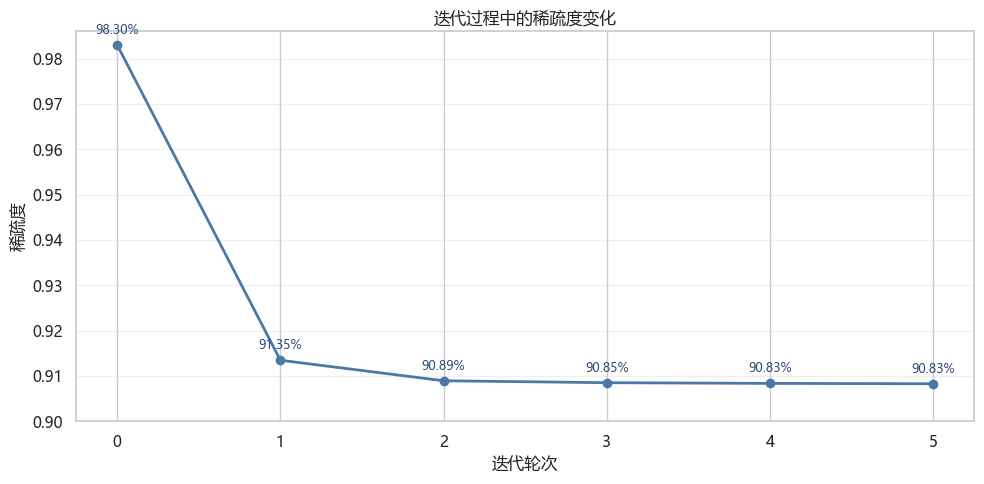

In [9]:
# 在迭代曲线中加入原始矩阵稀疏度，便于和每轮过滤结果对比
initial_sparsity = 1 - (initial_matrix.notna().sum().sum() / initial_matrix.size)
plot_history_df = pd.concat(
    [
        pd.DataFrame({"iteration": [0], "sparsity_after": [initial_sparsity]}),
        history_df[["iteration", "sparsity_after"]].copy(),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plot_history_df["iteration"], plot_history_df["sparsity_after"], marker="o", linewidth=2, color="#4C78A8")

for x, y in zip(plot_history_df["iteration"], plot_history_df["sparsity_after"]):
    ax.annotate(
        f"{y:.2%}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        color="#2F4B7C",
    )

ax.set_title("迭代过程中的稀疏度变化")
ax.set_xlabel("迭代轮次")
ax.set_ylabel("稀疏度")
ax.set_xticks(plot_history_df["iteration"])
ax.set_ylim(0.90, max(0.985, float(plot_history_df["sparsity_after"].max()) + 0.003))
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 过滤前后分布对比
下面从用户侧和电影侧分别比较过滤前后评分数量的分布差异，并用箱线图概括中位数、四分位数与异常值。

C:\Users\述\AppData\Local\Temp\ipykernel_62920\3864994783.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_box_df, x="状态", y="评分条数", ax=axes[0, 1], palette=["#4C78A8", "#F58518"])
C:\Users\述\AppData\Local\Temp\ipykernel_62920\3864994783.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movie_box_df, x="状态", y="评分条数", ax=axes[1, 1], palette=["#4C78A8", "#F58518"])


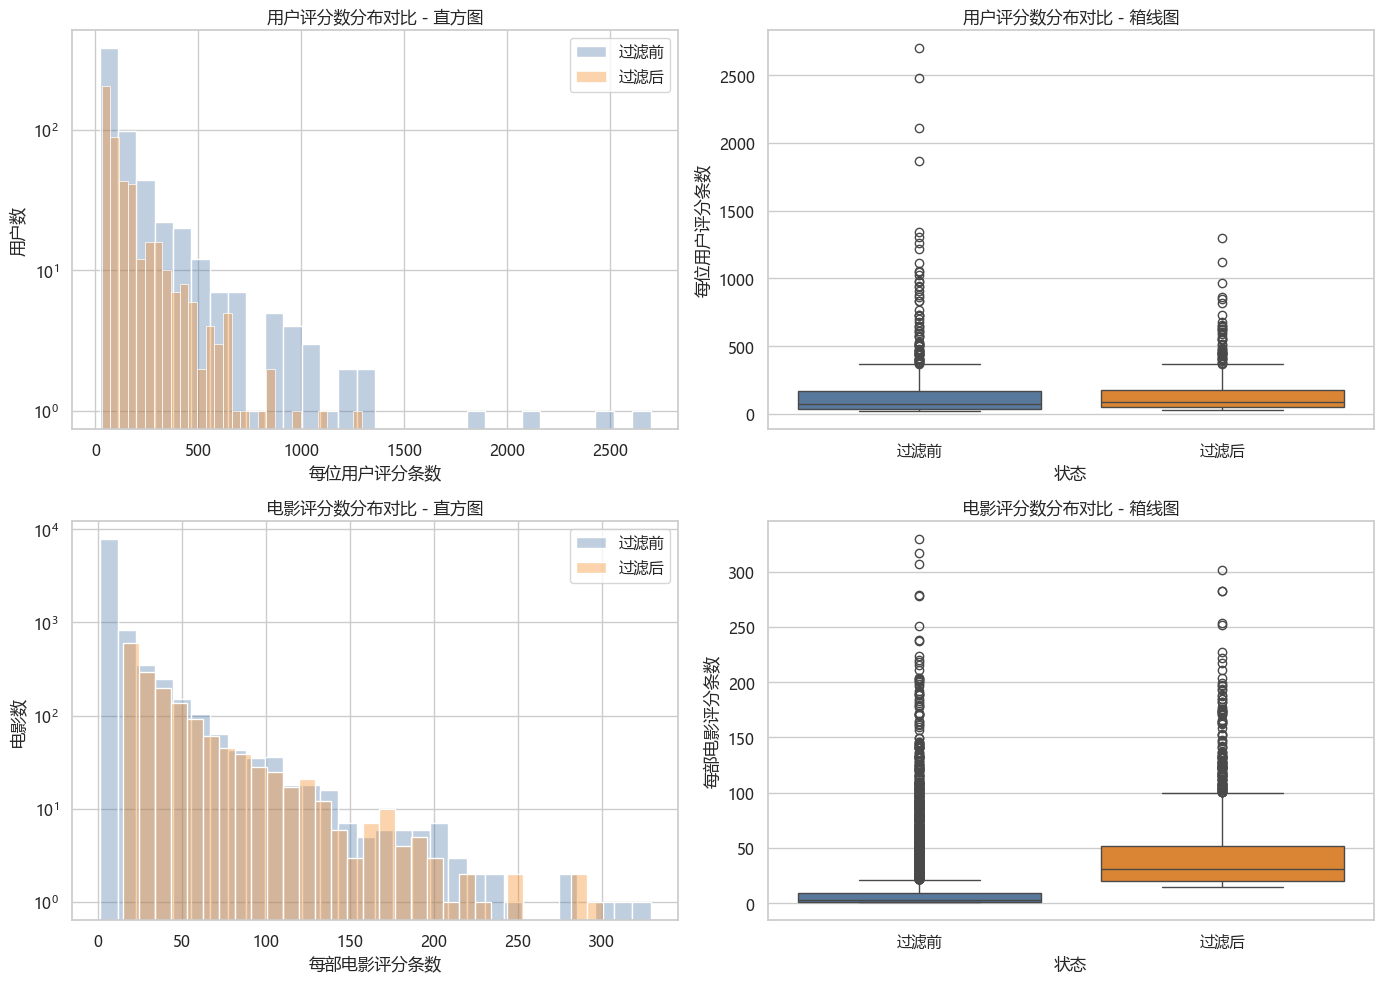

In [10]:
# 统计过滤后每位用户、每部电影仍保留的评分数量
final_user_rating_counts = final_matrix.notna().sum(axis=1)
final_movie_rating_counts = final_matrix.notna().sum(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    user_rating_counts,
    bins=30,
    ax=axes[0, 0],
    color="#4C78A8",
    alpha=0.35,
    edgecolor="white",
    label="过滤前",
)
sns.histplot(
    final_user_rating_counts,
    bins=30,
    ax=axes[0, 0],
    color="#F58518",
    alpha=0.35,
    edgecolor="white",
    label="过滤后",
)
axes[0, 0].set_title("用户评分数分布对比 - 直方图")
axes[0, 0].set_xlabel("每位用户评分条数")
axes[0, 0].set_ylabel("用户数")
axes[0, 0].set_yscale("log")
axes[0, 0].legend()

user_box_df = pd.DataFrame(
    {
        "评分条数": pd.concat([user_rating_counts, final_user_rating_counts], ignore_index=True),
        "状态": ["过滤前"] * len(user_rating_counts) + ["过滤后"] * len(final_user_rating_counts),
    }
)
sns.boxplot(data=user_box_df, x="状态", y="评分条数", ax=axes[0, 1], palette=["#4C78A8", "#F58518"])
axes[0, 1].set_title("用户评分数分布对比 - 箱线图")
axes[0, 1].set_xlabel("状态")
axes[0, 1].set_ylabel("每位用户评分条数")

sns.histplot(
    movie_rating_counts,
    bins=30,
    ax=axes[1, 0],
    color="#4C78A8",
    alpha=0.35,
    edgecolor="white",
    label="过滤前",
)
sns.histplot(
    final_movie_rating_counts,
    bins=30,
    ax=axes[1, 0],
    color="#F58518",
    alpha=0.35,
    edgecolor="white",
    label="过滤后",
)
axes[1, 0].set_title("电影评分数分布对比 - 直方图")
axes[1, 0].set_xlabel("每部电影评分条数")
axes[1, 0].set_ylabel("电影数")
axes[1, 0].set_yscale("log")
axes[1, 0].legend()

movie_box_df = pd.DataFrame(
    {
        "评分条数": pd.concat([movie_rating_counts, final_movie_rating_counts], ignore_index=True),
        "状态": ["过滤前"] * len(movie_rating_counts) + ["过滤后"] * len(final_movie_rating_counts),
    }
)
sns.boxplot(data=movie_box_df, x="状态", y="评分条数", ax=axes[1, 1], palette=["#4C78A8", "#F58518"])
axes[1, 1].set_title("电影评分数分布对比 - 箱线图")
axes[1, 1].set_xlabel("状态")
axes[1, 1].set_ylabel("每部电影评分条数")

plt.tight_layout()
plt.show()


## 过滤前后热图对比
这一部分把过滤前后的块密度热图并排展示，方便观察高密度区域是否更加集中。

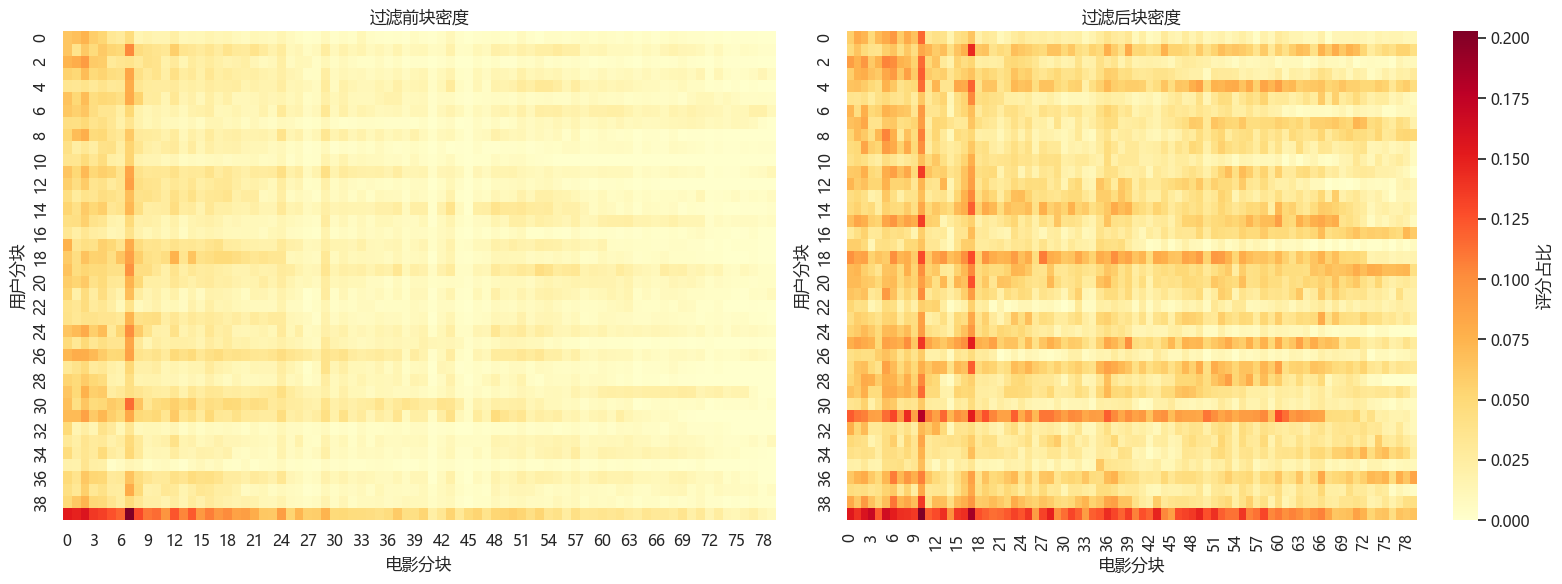

In [11]:
# 对过滤后的矩阵做同样的块压缩，便于和过滤前热力图直接对照
density_after = block_density(final_matrix.notna(), row_bins=40, col_bins=80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(density_before, cmap="YlOrRd", cbar_kws={"label": "评分占比"})
sns.heatmap(density_before, cmap="YlOrRd", cbar=False, ax=axes[0])
axes[0].set_title("过滤前块密度")
axes[0].set_xlabel("电影分块")
axes[0].set_ylabel("用户分块")

sns.heatmap(density_after, cmap="YlOrRd", cbar=False, ax=axes[1])
axes[1].set_title("过滤后块密度")
axes[1].set_xlabel("电影分块")
axes[1].set_ylabel("用户分块")

plt.tight_layout()
plt.show()

## 关键指标对比表
表格汇总过滤前后在用户数、电影数、评分数和稀疏度等方面的整体变化。

In [12]:
# 汇总过滤前后的关键指标，便于在一张表中观察整体变化
initial_summary = matrix_summary(initial_matrix)
final_summary = matrix_summary(final_matrix)

comparison_df = pd.DataFrame(
    {
        "指标": ["用户数", "电影数", "评分数", "矩阵单元数", "稀疏率", "密度", "用户平均评分数", "电影平均评分数"],
        "过滤前": [
            int(initial_summary["users"]),
            int(initial_summary["movies"]),
            int(initial_summary["ratings"]),
            int(initial_summary["cells"]),
            f"{initial_summary['sparsity']:.2%}",
            f"{initial_summary['density']:.2%}",
            f"{initial_summary['avg_user_ratings']:.2f}",
            f"{initial_summary['avg_movie_ratings']:.2f}",
        ],
        "过滤后": [
            int(final_summary["users"]),
            int(final_summary["movies"]),
            int(final_summary["ratings"]),
            int(final_summary["cells"]),
            f"{final_summary['sparsity']:.2%}",
            f"{final_summary['density']:.2%}",
            f"{final_summary['avg_user_ratings']:.2f}",
            f"{final_summary['avg_movie_ratings']:.2f}",
        ],
    }
)
display(comparison_df)

print("迭代轮次:", len(history_df))
print("最终阈值: user >= 30, movie >= 15")
print("最终矩阵形状:", final_matrix.shape)
print("最终稀疏率:", f"{matrix_sparsity(final_matrix):.2%}")
print("评分保留数:", int(final_matrix.notna().sum().sum()))
print("评分保留率:", f"{final_matrix.notna().sum().sum() / initial_matrix.notna().sum().sum():.2%}")

,指标,过滤前,过滤后
0,用户数,610,475
1,电影数,9724,1617
2,评分数,100836,70454
3,矩阵单元数,5931640,768075
4,稀疏率,1.70%,9.17%
5,密度,98.30%,90.83%
6,用户平均评分数,165.30,148.32
7,电影平均评分数,10.37,43.57


迭代轮次: 5
最终阈值: user >= 30, movie >= 15
最终矩阵形状: (475, 1617)
最终稀疏率: 90.83%
评分保留数: 70454
评分保留率: 69.87%


## 保存结果
最后将处理后的矩阵写回数据目录，并简单校验保存后的文件规模。

In [13]:
# 将过滤后的矩阵覆盖保存到 cleaned_data 目录，供后续建模直接使用
DATA_DIR.mkdir(parents=True, exist_ok=True)
final_matrix.to_csv(FILTERED_PATH, encoding="utf-8")

verify_matrix = pd.read_csv(FILTERED_PATH, index_col=0)
print("已保存:", FILTERED_PATH)
print("保存后文件形状:", verify_matrix.shape)
print("保存后评分数:", int(verify_matrix.notna().sum().sum()))

已保存: D:\Movie-Recommender-System\data\cleaned_data\user_item_matrix_sparse_filtered.csv
保存后文件形状: (475, 1617)
保存后评分数: 70454


## 小结

本次过滤保留了活跃用户与热门电影的核心交叉区域，同时把稀疏率明显压低到更适合后续协同过滤建模的水平。